---
tags: [algorithm, primitive, simulation]
---

# Suzuki–Trotter分解によるハミルトニアンシミュレーション (Rabi振動)

量子系の時間発展$e^{-iHt}$をシミュレーションすることは、量子コンピュータの代表的な応用の1つです。ハミルトニアンが非可換な部分に分割されるとき、つまり$H = A + B$かつ$[A, B] \neq 0$のとき、素朴な分解$e^{-i(A+B)t} = e^{-iAt}\,e^{-iBt}$は成立しません。標準的な対処法が**Trotter–Suzuki積公式**で、各項の短時間発展を交互に並べます。誤差は、ステップ幅を小さくすれば減り(Lie–Trotter、1次)、ステップを対称化すれば減り(Strang、2次)、対称ステップをSuzukiの構成で再帰的に入れ子にすればさらに減ります(任意の偶数次)。

本記事では、Trotter誤差が測定しやすい1量子ビットのRabiハミルトニアンを題材に、これらの近似をQamomileで最初から組み立てます。まず$S_1$と$S_2$を書き、続いて**自己再帰**な`@qkernel`としてSuzukiフラクタル再帰全体を記述します。目標次数を`UInt`パラメータで受け取れば、トランスパイラは具体値が結び付いた`order`の下でinline + partial-evaluationの固定点ループにより再帰を解決します。再帰が何層であっても、生成される回路はフラットです。最後に、教科書通りの収束次数($S_k$のフィデリティ誤差が$\Delta t^{2k}$でスケールすること)を、2x2のプロパゲータの厳密解と照合して確認します。

In [1]:
# 最新のQamomileをpipからインストールします！
# !pip install "qamomile[qiskit]"

In [2]:
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
from qiskit import QuantumCircuit, transpile as qk_transpile
from qiskit_aer import AerSimulator
from scipy.linalg import expm

import qamomile.circuit as qmc
import qamomile.observable as qm_o
from qamomile.circuit.algorithm import trotterized_time_evolution
from qamomile.qiskit import QiskitTranspiler

## Rabiハミルトニアン

共鳴駆動される2準位系は次のハミルトニアンで記述されます:

$$ H = \underbrace{\tfrac{\omega}{2} Z}_{H_z} + \underbrace{\tfrac{\Omega}{2} X}_{H_x}. $$

$[Z, X] \neq 0$なので、$H$を$H_z$と$H_x$に分割するとTrotter誤差が生じ、1量子ビットでも明確に観測できます。初期状態$|0\rangle$から始めると、励起確率は$P_{|1\rangle}(t) = (\Omega/E)^2 \sin^2(Et/2)$に従って振動します。ただし$E = \sqrt{\omega^2 + \Omega^2}$です。

Qamomileでは、$H_z$と$H_x$を2つの`Observable`として構築し、Pythonのリストに詰めます。`@qkernel`ではそのリストを`Vector[Observable]`として宣言します。トランスパイル時にリストをバインドすると、`Hs.shape[0]`上の反復は項ごとの`pauli_evolve`呼び出しへ展開されます。

In [3]:
omega = 1.2
Omega = 0.8
T = 1.5

Hz = 0.5 * omega * qm_o.Z(0)
Hx = 0.5 * Omega * qm_o.X(0)
Hs = [Hz, Hx]

### $[H_z, H_x] \neq 0$ の確認

Trotter近似が必要になるのは$H_z$と$H_x$が可換でないからです。`qamomile.observable.commutator(a, b)`はハミルトニアン同士の交換子$[a, b] = a b - b a$を直接計算します。内部では各Pauli列ペアを1度だけ走査し、qubitパリティの規則(2つのPauli列は、両方とも非恒等かつ異なるPauliが乗っているqubitの数が奇数のときにだけ反交換)に従って、可換なペアを積を作る前に落とします。`Hz * Hx - Hx * Hz`のように一旦展開してから打ち消す素朴な計算より軽く、結果として完全に簡約された`Hamiltonian`が返ってくるので、そのまま検査したり解析値と比較したりできます。

Rabiハミルトニアンの場合、教科書的な値は

$$ [H_z, H_x] \;=\; \tfrac{\omega \Omega}{4}\,[Z, X] \;=\; i\,\tfrac{\omega \Omega}{2}\, Y $$

であり、`commutator`はこれを厳密に再現します:

In [4]:
comm_zx = qm_o.commutator(Hz, Hx)
print(comm_zx)

expected = 1j * 0.5 * omega * Omega * qm_o.Y(0)
assert comm_zx == expected

Hamiltonian((Y0,): 0.48j)


## 厳密な参照状態

2x2行列の指数関数で厳密な状態$|\psi(T)\rangle = e^{-iHT}|0\rangle$が得られます。各Trotter近似は**フィデリティ誤差**$1 - |\langle\psi_\text{exact}|\psi_\text{trotter}\rangle|$によってこの状態と比較します。

In [5]:
X_mat = np.array([[0, 1], [1, 0]], dtype=complex)
Z_mat = np.array([[1, 0], [0, -1]], dtype=complex)
H_mat = 0.5 * omega * Z_mat + 0.5 * Omega * X_mat
sv_exact = expm(-1j * T * H_mat) @ np.array([1.0, 0.0], dtype=complex)

In [6]:
def statevector(circuit) -> np.ndarray:
    """測定を取り除き、PauliEvolutionGateを展開して状態ベクトルを読み出します。

    デフォルトの``pauli_evolve`` emitterは``PauliEvolutionGate``を生成しますが、
    これはAerSimulatorのネイティブ基底には含まれません。そこでシミュレーション前に、
    浅いQiskitのトランスパイルで基本回転ゲートに展開します。
    """
    stripped = QuantumCircuit(*circuit.qregs)
    for instr in circuit.data:
        if instr.operation.name not in ("measure", "save_statevector"):
            stripped.append(instr)
    stripped = qk_transpile(
        stripped,
        basis_gates=["u", "cx", "rx", "ry", "rz", "h", "p", "sx", "x", "y", "z"],
    )
    # ``save_statevector`` は qiskit-aer が ``QuantumCircuit`` に monkey-patch
    # するメソッドで、base qiskit の typeshed には存在しない。
    stripped.save_statevector()  # type: ignore[attr-defined]
    sim = AerSimulator(method="statevector")
    return np.asarray(sim.run(stripped).result().get_statevector())

## $S_1$: 1次Suzuki–Trotter分解 (Lie–Trotter)

もっとも単純な分解は

$$ S_1(\Delta t) = e^{-i H_x \Delta t}\, e^{-i H_z \Delta t} $$

で、これを$N$回適用して全発展時間$T = N \Delta t$をシミュレーションします。1ステップあたりの局所誤差は$O(\Delta t^2)$、$N = T/\Delta t$ステップにわたる大域的な状態ノルム誤差は$O(\Delta t)$です。

1ステップを小さな補助`@qkernel`として書きます。量子ビットレジスタを$H_z$、続いて$H_x$で発展させるだけです。外側のカーネル`rabi_s1`はそのステップを$N$回繰り返します。`n_steps`は`UInt`パラメータなので、同じカーネルが任意の$N$についてバインド時にトランスパイルできます。

In [7]:
@qmc.qkernel
def s1_step(
    q: qmc.Vector[qmc.Qubit], Hs: qmc.Vector[qmc.Observable], dt: qmc.Float
) -> qmc.Vector[qmc.Qubit]:
    q = qmc.pauli_evolve(q, Hs[0], dt)
    q = qmc.pauli_evolve(q, Hs[1], dt)
    return q

In [8]:
@qmc.qkernel
def rabi_s1(
    Hs: qmc.Vector[qmc.Observable], dt: qmc.Float, n_steps: qmc.UInt
) -> qmc.Vector[qmc.Bit]:
    q = qmc.qubit_array(1, "q")
    for _ in qmc.range(n_steps):
        q = s1_step(q, Hs, dt)
    return qmc.measure(q)

## $S_2$: 2次Suzuki–Trotter分解 (Strang分解)

中央の項を中心にステップを対称化すると先頭の誤差項が消えます:

$$ S_2(\Delta t) = e^{-i H_z \Delta t/2}\, e^{-i H_x \Delta t}\, e^{-i H_z \Delta t/2}. $$

局所誤差は$O(\Delta t^3)$、大域的な状態ノルム誤差は$O(\Delta t^2)$になります。ステップカーネルは`pauli_evolve`を3回呼ぶだけです。

In [9]:
@qmc.qkernel
def s2_step(
    q: qmc.Vector[qmc.Qubit], Hs: qmc.Vector[qmc.Observable], dt: qmc.Float
) -> qmc.Vector[qmc.Qubit]:
    q = qmc.pauli_evolve(q, Hs[0], 0.5 * dt)
    q = qmc.pauli_evolve(q, Hs[1], dt)
    q = qmc.pauli_evolve(q, Hs[0], 0.5 * dt)
    return q

In [10]:
@qmc.qkernel
def rabi_s2(
    Hs: qmc.Vector[qmc.Observable], dt: qmc.Float, n_steps: qmc.UInt
) -> qmc.Vector[qmc.Bit]:
    q = qmc.qubit_array(1, "q")
    for _ in qmc.range(n_steps):
        q = s2_step(q, Hs, dt)
    return qmc.measure(q)

## 高次のSuzuki–Trotter分解:フラクタル再帰

鈴木増雄氏は、任意の偶数次Trotter近似を$S_2$から**再帰的に**構築できることを示しました。各段で5つのリスケーリングされたコピーを入れ子にします:

$$ S_{2k}(\Delta t) = S_{2k-2}(p_k \Delta t)^2 \, S_{2k-2}\bigl((1 - 4 p_k)\Delta t\bigr) \, S_{2k-2}(p_k \Delta t)^2. $$

ここで段ごとの係数は

$$ p_k = \frac{1}{4 - 4^{1/(2k-1)}} $$

です。$p_k$は下位の公式の$(2k-1)$次誤差がキャンセルされるように選ばれているので、1ステップあたりの局所誤差は$O(\Delta t^{2k+1})$になります。**係数は段ごとに必ず計算し直す必要があります。** 具体的には:

- $k=2$ (4次): $p_2 = 1/(4 - 4^{1/3}) \approx 0.4145$
- $k=3$ (6次): $p_3 = 1/(4 - 4^{1/5}) \approx 0.3731$
- $k=4$ (8次): $p_4 = 1/(4 - 4^{1/7}) \approx 0.3596$

すべての段で$p_2$を使い回すと$(2k-1)$次の誤差項が残ったままになり、結果として得られる公式は$S_4$とほぼ同等の精度しか持ちません。これはSuzuki-Trotterを手書きで実装するときにハマりがちな罠です。

### 自己再帰`@qkernel`として再帰を書く

この数学的な再帰は`@qkernel`にそのまま翻訳できます。目標次数を`UInt`パラメータで受け取り、再帰ブランチで`order - 2`を引数にして自分自身を呼び出します。基底ケースである`order == 2`では`s2_step`に処理を渡し、そうでなければ5回の入れ子呼び出しでSuzukiフラクタルを生成します。

Qamomileのトランスパイラは、具体値が結び付いた`order`の下で**inline + partial-evaluationの固定点ループ**を回すことで自己再帰カーネルを解決します。各イテレーションが`CallBlockOp`の1層を展開し、現在の`order`値を使って基底ケースの`if`を畳み込みます。再帰が何層であっても生成される回路はフラットなので、トランスパイル時に`order=8`をバインドすれば、公式を手書きすることなく具体的な8次のSuzuki回路が得られます。

事前に知っておくべき注意点が2つあります:

- **`order`はトランスパイル時に具体値である必要があります。** バインドがないと基底ケースの`if`が畳み込まれず、展開ループが停止条件を得られません。トランスパイラは自己呼び出しをIRに残し、バックエンドのemitで拒否されます。
- **停止しない再帰は検出されます。** ボディが`order - 2`ではなく`order + 2`で自分を呼んでいる場合など、基底ケースに到達しない再帰は、展開ループが深さ上限を使い切った時点で`FrontendTransformError`を送出します(古典的な`RecursionError`に相当します)。

In [11]:
@qmc.qkernel
def suzuki_trotter(
    order: qmc.UInt,
    q: qmc.Vector[qmc.Qubit],
    Hs: qmc.Vector[qmc.Observable],
    dt: qmc.Float,
) -> qmc.Vector[qmc.Qubit]:
    if order == 2:
        q = s2_step(q, Hs, dt)
    else:
        p = 1.0 / (4.0 - 4.0 ** (1.0 / (order - 1)))
        w = 1.0 - 4.0 * p
        q = suzuki_trotter(order - 2, q, Hs, p * dt)
        q = suzuki_trotter(order - 2, q, Hs, p * dt)
        q = suzuki_trotter(order - 2, q, Hs, w * dt)
        q = suzuki_trotter(order - 2, q, Hs, p * dt)
        q = suzuki_trotter(order - 2, q, Hs, p * dt)
    return q

In [12]:
@qmc.qkernel
def rabi_suzuki(
    order: qmc.UInt,
    Hs: qmc.Vector[qmc.Observable],
    dt: qmc.Float,
    n_steps: qmc.UInt,
) -> qmc.Vector[qmc.Bit]:
    q = qmc.qubit_array(1, "q")
    for _ in qmc.range(n_steps):
        q = suzuki_trotter(order, q, Hs, dt)
    return qmc.measure(q)

`rabi_suzuki`はトランスパイル時の`order`バインドを変えるだけで$S_2$、$S_4$、$S_6$、$S_8$、……のいずれも生成できる、単一のカーネルです。次数ごとに別のカーネルを書く必要はありません。

### ショートカット: `qamomile.circuit.algorithm`の`trotterized_time_evolution`

ここまで`s1_step` / `s2_step` / `suzuki_trotter`と外側のステップループを手で書き下してきたのは、再帰の流れを追うのに役立つからです。一方で日常的な用途には、同じ構成をそのまま使える既製のヘルパーが[`qamomile.circuit.algorithm.trotter`](../../../qamomile/circuit/algorithm/trotter.py)にあります。

In [13]:
@qmc.qkernel
def rabi_from_algorithm(
    Hs: qmc.Vector[qmc.Observable],
    gamma: qmc.Float,
    order: qmc.UInt,
    step: qmc.UInt,
) -> qmc.Vector[qmc.Bit]:
    q = qmc.qubit_array(1, name="q")
    q = trotterized_time_evolution(q, Hs, order, gamma, step)
    return qmc.measure(q)

このヘルパーは`order = 1`または任意の正の偶数を受け付け、`gamma / step`の幅のTrotterスライスを`step`回適用します。したがって本記事以降のプロットは、この1つのカーネルに`order`と`step`をバインドするだけで再現できます。分割をカスタマイズする必要がなければこちらを使い、項ごとのゲートスケジュールを確認したり手で調整したりしたい場合には上の明示的な形に戻してください。

## $N = 8$での簡易チェック

収束性のスイープを行う前に、各カーネルを一度トランスパイルし、状態ベクトルが妥当な範囲に収まることを確認します。$S_1$と$S_2$は専用カーネルを使い、$S_4$と$S_6$はそれぞれ対応する`order`バインドで`rabi_suzuki`から生成します。

In [14]:
tr = QiskitTranspiler()
N_demo = 8
s1_s2_kernels = {"S1": rabi_s1, "S2": rabi_s2}
suzuki_orders = {"S4": 4, "S6": 6}

for name, ker in s1_s2_kernels.items():
    exe = tr.transpile(ker, bindings={"Hs": Hs, "dt": T / N_demo, "n_steps": N_demo})
    sv = statevector(exe.compiled_quantum[0].circuit)
    err = 1.0 - abs(np.vdot(sv_exact, sv))
    print(f"{name} at N={N_demo}: fidelity error = {err:.3e}")

for name, order in suzuki_orders.items():
    exe = tr.transpile(
        rabi_suzuki,
        bindings={"order": order, "Hs": Hs, "dt": T / N_demo, "n_steps": N_demo},
    )
    sv = statevector(exe.compiled_quantum[0].circuit)
    err = 1.0 - abs(np.vdot(sv_exact, sv))
    print(f"{name} at N={N_demo}: fidelity error = {err:.3e}")

S1 at N=8: fidelity error = 1.183e-03
S2 at N=8: fidelity error = 1.059e-06


S4 at N=8: fidelity error = 1.468e-13


S6 at N=8: fidelity error = -2.220e-16


## 収束性のスイープ

Trotterステップ数$N$を掃引し、ステップ幅$\Delta t = T / N$に対してフィデリティ誤差を両対数軸でプロットします。期待される傾きは以下のとおりです:

| 公式 | 局所誤差 | 大域ノルム誤差 | フィデリティ誤差 ($1 -$ 内積) |
|-----|---------|---------------|------------------------------|
| $S_1$ | $O(\Delta t^2)$ | $O(\Delta t)$   | $O(\Delta t^2)$  |
| $S_2$ | $O(\Delta t^3)$ | $O(\Delta t^2)$ | $O(\Delta t^4)$  |
| $S_4$ | $O(\Delta t^5)$ | $O(\Delta t^4)$ | $O(\Delta t^8)$  |
| $S_6$ | $O(\Delta t^7)$ | $O(\Delta t^6)$ | $O(\Delta t^{12})$ |

フィデリティ誤差は状態ノルム誤差の**2乗**になります(先頭項)。2つのベクトルが十分近ければ$1 - |\langle a | b \rangle| \approx \tfrac{1}{2}\lVert a - b \rVert^2$なので、以下のプロットに現れる傾きは$1, 2, 4$ではなく$2, 4, 8$です。

In [15]:
Ns = np.array([2, 4, 8, 16, 32, 64])
all_names = ["S1", "S2", "S4", "S6"]
errors: dict[str, Any] = {name: [] for name in all_names}

for N in Ns:
    for name, ker in s1_s2_kernels.items():
        exe = tr.transpile(
            ker, bindings={"Hs": Hs, "dt": T / int(N), "n_steps": int(N)}
        )
        sv = statevector(exe.compiled_quantum[0].circuit)
        errors[name].append(1.0 - abs(np.vdot(sv_exact, sv)))
    for name, order in suzuki_orders.items():
        exe = tr.transpile(
            rabi_suzuki,
            bindings={"order": order, "Hs": Hs, "dt": T / int(N), "n_steps": int(N)},
        )
        sv = statevector(exe.compiled_quantum[0].circuit)
        errors[name].append(1.0 - abs(np.vdot(sv_exact, sv)))

errors = {k: np.asarray(v) for k, v in errors.items()}
dts = T / Ns

In [16]:
def fit_slope(dts, errs, n_points):
    return np.polyfit(np.log(dts[:n_points]), np.log(errs[:n_points]), 1)[0]

In [17]:
slope_s1 = fit_slope(dts, errors["S1"], len(Ns))
slope_s2 = fit_slope(dts, errors["S2"], len(Ns))
slope_s4 = fit_slope(dts, errors["S4"], 3)
print(f"Fitted slopes:  S1 = {slope_s1:.2f}  S2 = {slope_s2:.2f}  S4 = {slope_s4:.2f}")
print(f"S6 fidelity error at largest dt: {errors['S6'][0]:.3e}")

# 期待される次数を保証し、pauli_evolveのリグレッションをdocs testで検出できるようにします
assert 1.7 < slope_s1 < 2.3, slope_s1
assert 3.7 < slope_s2 < 4.3, slope_s2
assert 7.0 < slope_s4 < 9.0, slope_s4
# S6は1量子ビットのこの問題ではfloat64の精度下限に張り付くので、
# 同じdtにおけるS4の主要誤差と比べて十分小さいことだけ確認します。
assert abs(errors["S6"][0]) < 1e-10, errors["S6"][0]

Fitted slopes:  S1 = 2.03  S2 = 4.01  S4 = 8.05
S6 fidelity error at largest dt: 8.105e-15


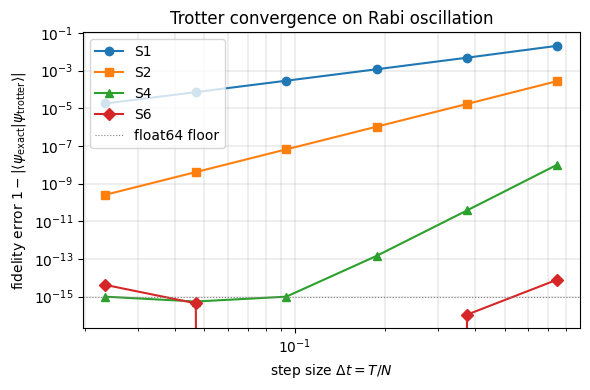

In [18]:
fig, ax = plt.subplots(figsize=(6, 4))
markers = {"S1": "o", "S2": "s", "S4": "^", "S6": "D"}
for name in all_names:
    ax.loglog(dts, errors[name], marker=markers[name], label=name)
ax.axhline(1e-15, color="grey", linestyle=":", linewidth=0.8, label="float64 floor")
ax.set_xlabel(r"step size $\Delta t = T / N$")
ax.set_ylabel(
    r"fidelity error $1 - |\langle \psi_{\rm exact} | \psi_{\rm trotter} \rangle|$"
)
ax.set_title("Trotter convergence on Rabi oscillation")
ax.grid(True, which="both", linewidth=0.3)
ax.legend()
fig.tight_layout()
plt.show()

プロット上の各直線の傾きは$\approx 2, 4, 8$で、上の表のフィデリティ誤差の次数と一致しています。$S_4$は$N = 16$の時点でfloat64の精度下限に到達し、$S_6$はスイープの全域で精度下限に張り付いているため直線が平坦に見えます(期待される$\Delta t^{12}$の傾きは、1量子ビット問題を倍精度で解く限り検出できません)。

## まとめ

- **モデル**: 1量子ビットのRabiハミルトニアン$H = H_z + H_x$。非可換な2項の和でTrotter誤差が測定可能です。
- **`Vector[Observable]` + `pauli_evolve`**: 時間発展ステップの自然なプリミティブです。ハミルトニアンリストをトランスパイル時にバインドすると、`Hs.shape[0]`上の反復が項ごとの発展へ展開されます。
- **Suzuki–Trotterフラクタル**: $S_{2k}$は$S_{2k-2}$のリスケーリングされた5つのコピーを段ごとの係数$p_k = 1/(4 - 4^{1/(2k-1)})$で入れ子にして構築します。段をまたいで同じ定数を使い回すのはよくある罠で、フラクタルの構成にはなりません。
- **再帰**: 数学的な再帰を`order: UInt`を受け取る自己再帰`@qkernel`としてそのまま記述できます。トランスパイラが具体値の`order`バインドの下でinline + partial-evalを回し、フラットな回路を出力します。バインドがなければ自己呼び出しがIRに残り、停止しない再帰は`FrontendTransformError`で検出されます。
- **収束**: 両対数プロット上の傾き$2, 4, 8$は教科書通りのTrotter次数と一致します。また、`dt`と`n_steps`がシンボリックパラメータなので、回路構造を作り直さずにステップ幅を掃引できます。